In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# All 25 James Bond films — title, year, actor, budget, revenue, IMDB rating
data = {
    'Title': [
        'Dr. No', 'From Russia with Love', 'Goldfinger', 'Thunderball',
        'You Only Live Twice', "On Her Majesty's Secret Service", 'Diamonds Are Forever',
        'Live and Let Die', 'The Man with the Golden Gun', 'The Spy Who Loved Me',
        'Moonraker', 'For Your Eyes Only', 'Octopussy', 'A View to a Kill',
        'The Living Daylights', 'Licence to Kill', 'GoldenEye', 'Tomorrow Never Dies',
        'The World Is Not Enough', 'Die Another Day', 'Casino Royale',
        'Quantum of Solace', 'Skyfall', 'SPECTRE', 'No Time to Die'
    ],
    'Year': [
        1962, 1963, 1964, 1965, 1967, 1969, 1971, 1973, 1974, 1977,
        1979, 1981, 1983, 1985, 1987, 1989, 1995, 1997, 1999, 2002,
        2006, 2008, 2012, 2015, 2021
    ],
    'Actor': [
        'Sean Connery', 'Sean Connery', 'Sean Connery', 'Sean Connery',
        'Sean Connery', 'George Lazenby', 'Sean Connery', 'Roger Moore',
        'Roger Moore', 'Roger Moore', 'Roger Moore', 'Roger Moore',
        'Roger Moore', 'Roger Moore', 'Timothy Dalton', 'Timothy Dalton',
        'Pierce Brosnan', 'Pierce Brosnan', 'Pierce Brosnan', 'Pierce Brosnan',
        'Daniel Craig', 'Daniel Craig', 'Daniel Craig', 'Daniel Craig', 'Daniel Craig'
    ],
    'Budget_M': [
        1.0, 2.0, 3.0, 6.8, 9.5, 7.0, 7.2, 7.0, 7.0, 14.0,
        34.0, 28.0, 27.5, 30.0, 40.0, 32.0, 60.0, 110.0, 135.0, 142.0,
        150.0, 200.0, 200.0, 245.0, 250.0
    ],
    'Revenue_M': [
        59.6, 78.9, 124.9, 141.2, 111.6, 64.6, 116.0, 126.4, 97.6, 185.4,
        210.3, 195.3, 183.7, 152.4, 191.2, 156.2, 356.4, 333.5, 361.8, 431.9,
        594.2, 586.1, 1108.6, 880.7, 774.2
    ],
    'IMDB_Rating': [
        7.2, 7.4, 7.7, 7.0, 6.9, 6.7, 6.6, 6.7, 6.6, 7.1,
        7.0, 6.8, 6.6, 6.3, 6.7, 6.6, 7.2, 6.9, 6.9, 6.6,
        8.0, 6.6, 7.7, 6.9, 7.3
    ]
}

df = pd.DataFrame(data)
print(f"Total Bond films: {len(df)}")
print(f"\nBond Actors: {df['Actor'].unique()}")
print(f"\nYear range: {df['Year'].min()} - {df['Year'].max()}")
df.head()

Total Bond films: 25

Bond Actors: ['Sean Connery' 'George Lazenby' 'Roger Moore' 'Timothy Dalton'
 'Pierce Brosnan' 'Daniel Craig']

Year range: 1962 - 2021


,Title,Year,Actor,Budget_M,Revenue_M,IMDB_Rating
0,Dr. No,1962,Sean Connery,1.0,59.6,7.2
1,From Russia with Love,1963,Sean Connery,2.0,78.9,7.4
2,Goldfinger,1964,Sean Connery,3.0,124.9,7.7
3,Thunderball,1965,Sean Connery,6.8,141.2,7.0
4,You Only Live Twice,1967,Sean Connery,9.5,111.6,6.9


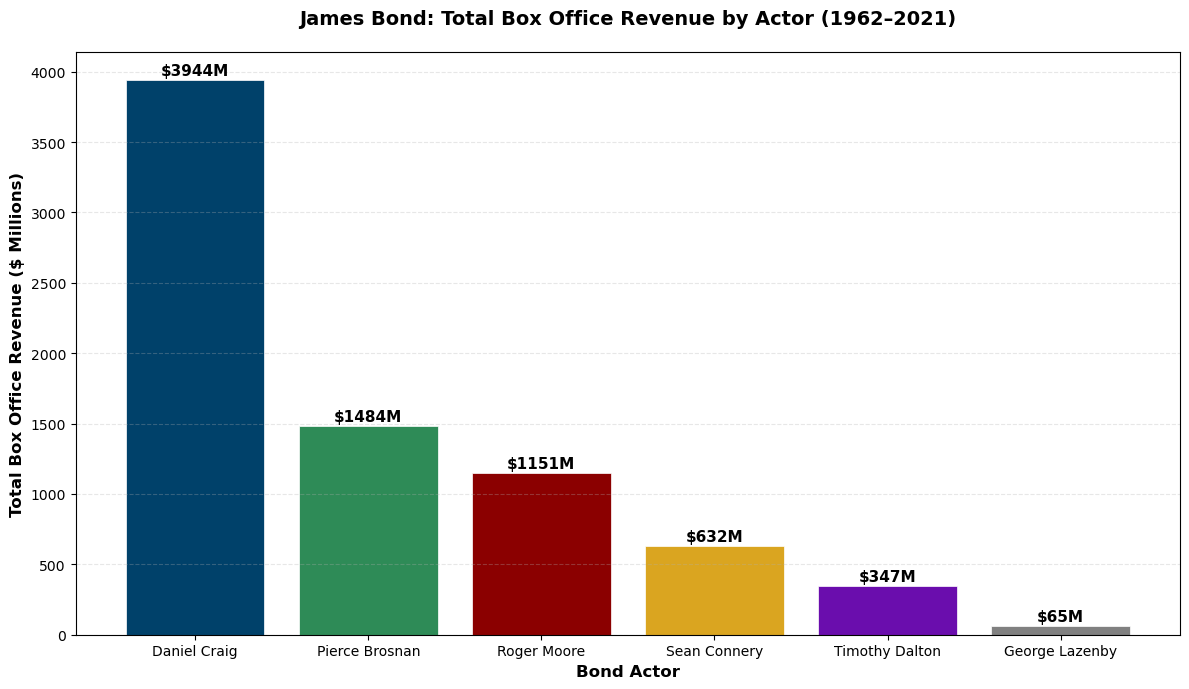

Chart 1 saved!


In [3]:
# CHART 1: Total Box Office Revenue by Bond Actor
actor_revenue = df.groupby('Actor')['Revenue_M'].sum().reset_index()
actor_revenue = actor_revenue.sort_values('Revenue_M', ascending=False)

# Signature colors per actor
actor_colors = {
    'Daniel Craig': '#00416A',
    'Roger Moore': '#8B0000',
    'Pierce Brosnan': '#2E8B57',
    'Sean Connery': '#DAA520',
    'Timothy Dalton': '#6A0DAD',
    'George Lazenby': 'gray'
}
colors = [actor_colors[actor] for actor in actor_revenue['Actor']]

plt.figure(figsize=(12, 7))
bars = plt.bar(actor_revenue['Actor'], actor_revenue['Revenue_M'], 
               color=colors, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, actor_revenue['Revenue_M']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'${val:.0f}M', ha='center', va='bottom', 
             fontsize=11, fontweight='bold')

plt.xlabel('Bond Actor', fontsize=12, fontweight='bold')
plt.ylabel('Total Box Office Revenue ($ Millions)', fontsize=12, fontweight='bold')
plt.title('James Bond: Total Box Office Revenue by Actor (1962–2021)', 
          fontsize=14, fontweight='bold', pad=20)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('bond_revenue_by_actor.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved!")

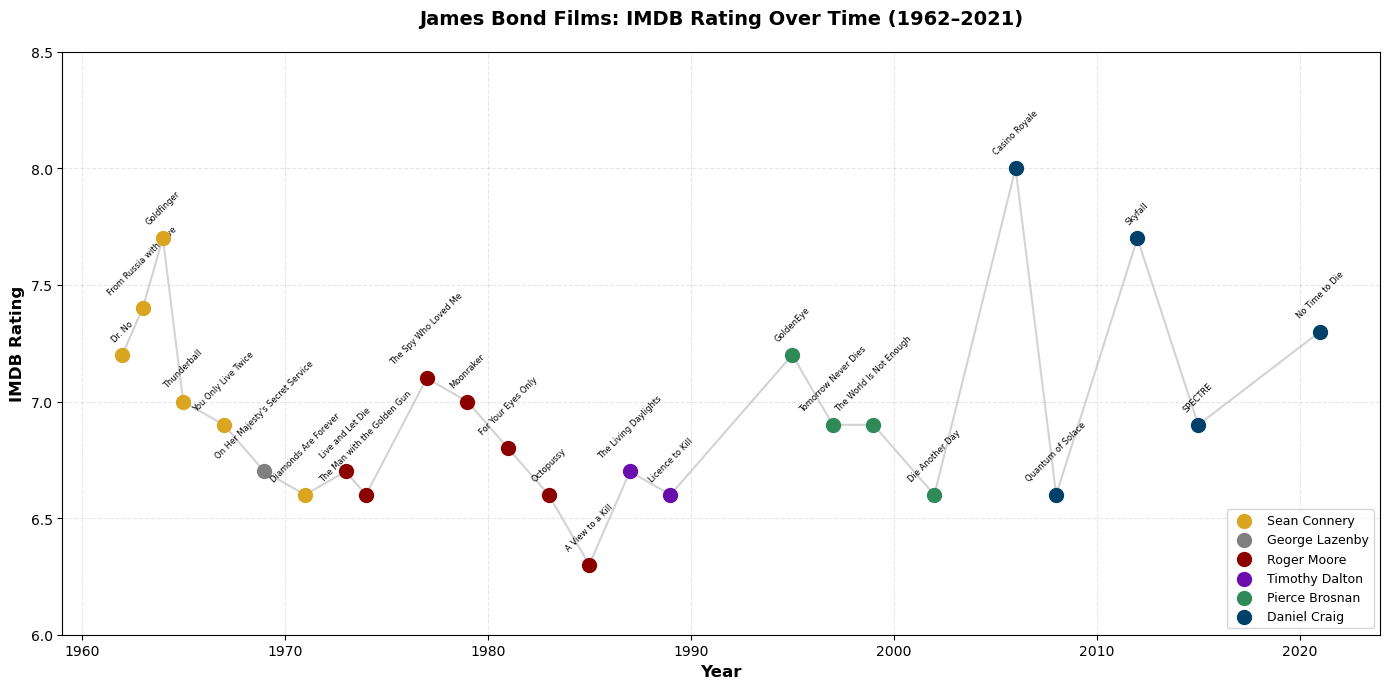

Chart 2 saved!


In [5]:
# CHART 2: IMDB Rating by Film Over Time
plt.figure(figsize=(14, 7))

actor_colors = {
    'Sean Connery': '#DAA520',
    'George Lazenby': 'gray',
    'Roger Moore': '#8B0000',
    'Timothy Dalton': '#6A0DAD',
    'Pierce Brosnan': '#2E8B57',
    'Daniel Craig': '#00416A'
}

# Plot line
plt.plot(df['Year'], df['IMDB_Rating'], color='lightgray', 
         linewidth=1.5, zorder=1)

# Plot colored dots per actor
for actor, color in actor_colors.items():
    mask = df['Actor'] == actor
    plt.scatter(df[mask]['Year'], df[mask]['IMDB_Rating'],
                color=color, s=100, zorder=5, label=actor)

# Add film title labels
for _, row in df.iterrows():
    plt.annotate(row['Title'], 
                xy=(row['Year'], row['IMDB_Rating']),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=6, rotation=45)

plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.ylabel('IMDB Rating', fontsize=12, fontweight='bold')
plt.title('James Bond Films: IMDB Rating Over Time (1962–2021)', 
          fontsize=14, fontweight='bold', pad=20)
plt.legend(loc='lower right', fontsize=9)
plt.ylim(6.0, 8.5)
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('bond_imdb_rating.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved!")

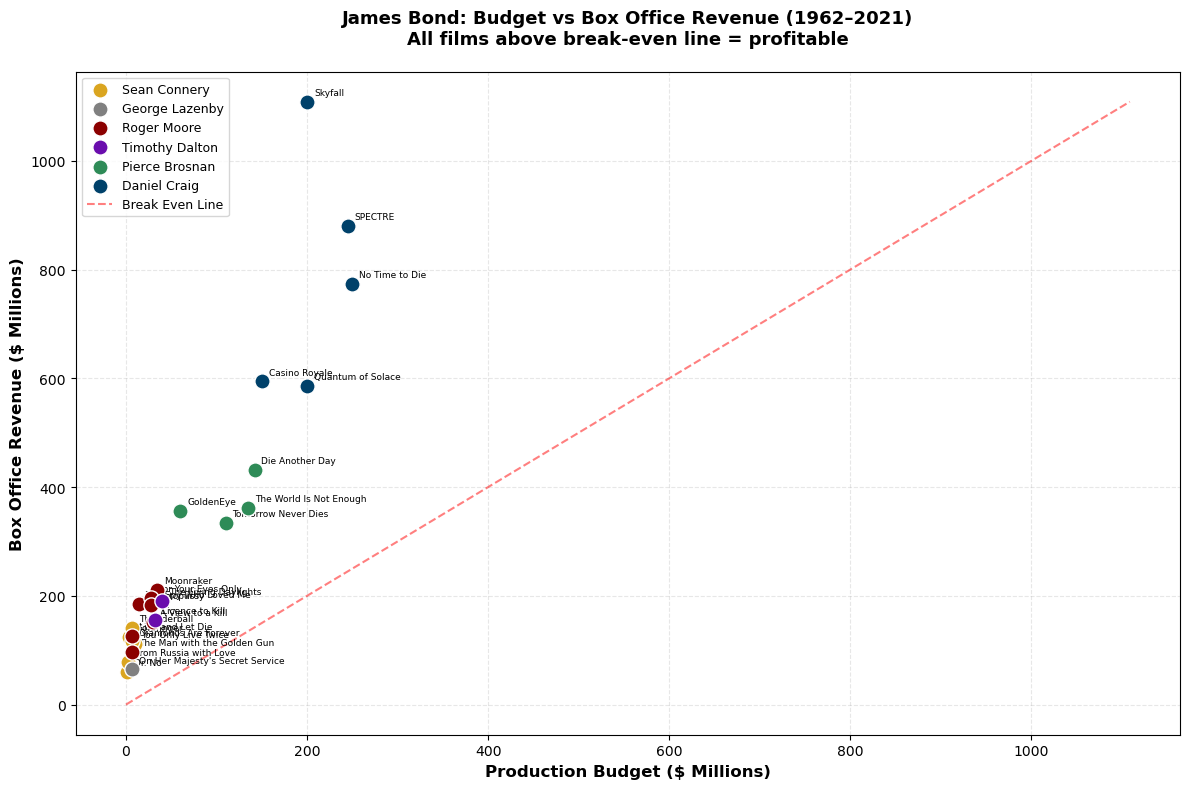

In [6]:
# CHART 3: Budget vs Revenue — Which Bond films were most profitable?
df['ROI'] = ((df['Revenue_M'] - df['Budget_M']) / df['Budget_M']) * 100

plt.figure(figsize=(12, 8))

for actor, color in actor_colors.items():
    mask = df['Actor'] == actor
    plt.scatter(df[mask]['Budget_M'], df[mask]['Revenue_M'],
                color=color, s=120, zorder=5, label=actor, edgecolors='white')

# Add film labels
for _, row in df.iterrows():
    plt.annotate(row['Title'],
                xy=(row['Budget_M'], row['Revenue_M']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=6.5)

# Add break even line
max_val = max(df['Budget_M'].max(), df['Revenue_M'].max())
plt.plot([0, max_val], [0, max_val], 'r--', 
         alpha=0.5, linewidth=1.5, label='Break Even Line')

plt.xlabel('Production Budget ($ Millions)', fontsize=12, fontweight='bold')
plt.ylabel('Box Office Revenue ($ Millions)', fontsize=12, fontweight='bold')
plt.title('James Bond: Budget vs Box Office Revenue (1962–2021)\nAll films above break-even line = profitable', 
          fontsize=13, fontweight='bold', pad=20)
plt.legend(loc='upper left', fontsize=9)
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('bond_budget_vs_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

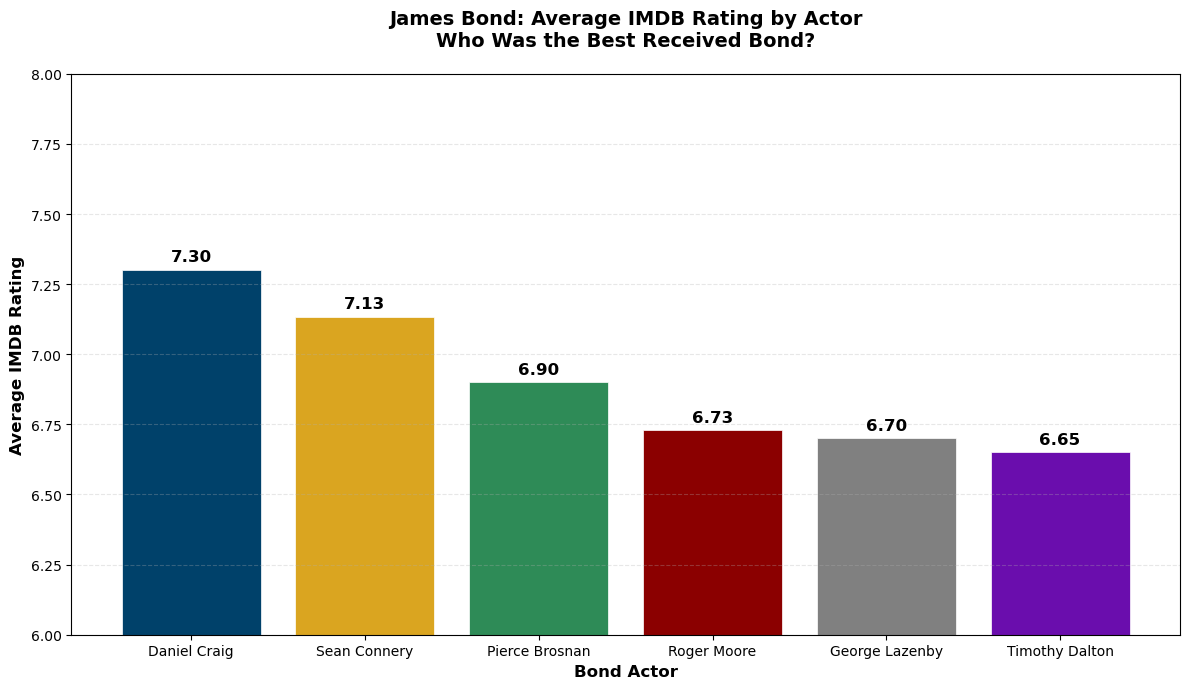

Chart 4 saved!


In [7]:
# CHART 4: Average IMDB Rating by Bond Actor
avg_rating = df.groupby('Actor')['IMDB_Rating'].mean().reset_index()
avg_rating = avg_rating.sort_values('IMDB_Rating', ascending=False)

colors = [actor_colors[actor] for actor in avg_rating['Actor']]

plt.figure(figsize=(12, 7))
bars = plt.bar(avg_rating['Actor'], avg_rating['IMDB_Rating'],
               color=colors, edgecolor='white', linewidth=0.5)

# Add rating labels on top of bars
for bar, val in zip(bars, avg_rating['IMDB_Rating']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.2f}', ha='center', va='bottom',
             fontsize=12, fontweight='bold')

plt.xlabel('Bond Actor', fontsize=12, fontweight='bold')
plt.ylabel('Average IMDB Rating', fontsize=12, fontweight='bold')
plt.title('James Bond: Average IMDB Rating by Actor\nWho Was the Best Received Bond?',
          fontsize=14, fontweight='bold', pad=20)
plt.ylim(6.0, 8.0)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('bond_avg_rating_by_actor.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved!")

In [8]:
print("""
================================================
JAMES BOND FILM ANALYSIS (1962-2021)
================================================
Dataset: 25 James Bond films, 6 Bond actors

KEY FINDINGS:
1. Daniel Craig generated the most total revenue ($3,944M)
2. Casino Royale (2006) is the highest rated Bond film (8.0 IMDB)
3. Daniel Craig has the highest average IMDB rating (7.30)
4. All Bond films were profitable — none fell below the break even line
5. Early Connery-era films had extraordinary ROI despite tiny budgets
6. Timothy Dalton is the lowest rated Bond actor on average (6.65)
7. Should be noted that adjusted for inflation Skyfall (2012) and Thunderball (1965) are the two highest grossing films while 
while License to Kill (1989) is the lowest

Tools: Python, pandas, matplotlib
""")


JAMES BOND FILM ANALYSIS (1962-2021)
Dataset: 25 James Bond films, 6 Bond actors

KEY FINDINGS:
1. Daniel Craig generated the most total revenue ($3,944M)
2. Casino Royale (2006) is the highest rated Bond film (8.0 IMDB)
3. Daniel Craig has the highest average IMDB rating (7.30)
4. All Bond films were profitable — none fell below the break even line
5. Early Connery-era films had extraordinary ROI despite tiny budgets
6. Timothy Dalton is the lowest rated Bond actor on average (6.65)
7. Should be noted that adjusted for inflation Skyfall (2012) and Thunderball (1965) are the two highest grossing films while 
while License to Kill (1989) is the lowest

Tools: Python, pandas, matplotlib

